# 1. 載入線性回歸模型相關套件

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pds
import numpy as npy
import matplotlib.pyplot as plot

# 2. 讀取糖果價格資料 (data114.csv)

In [24]:
# 讀取資料 (Windows 路徑格式)
dataframe = pds.read_csv('https://raw.githubusercontent.com/chihleebobo/0511/refs/heads/main/data114.csv')
print('=== 糖果價格資料集 ===')
print(dataframe.head())
print('\n總共有多少筆資料:', dataframe.shape)
print('這些資料的直行(欄位)名稱分別為:', dataframe.keys())

=== 糖果價格資料集 ===
   Mon  Height
0    0   52.23
1    1   57.20
2    2   63.00
3    3   65.80
4    4   68.50

總共有多少筆資料: (16, 2)
這些資料的直行(欄位)名稱分別為: Index(['Mon', 'Height'], dtype='object')


# 3. 視覺化資料分佈

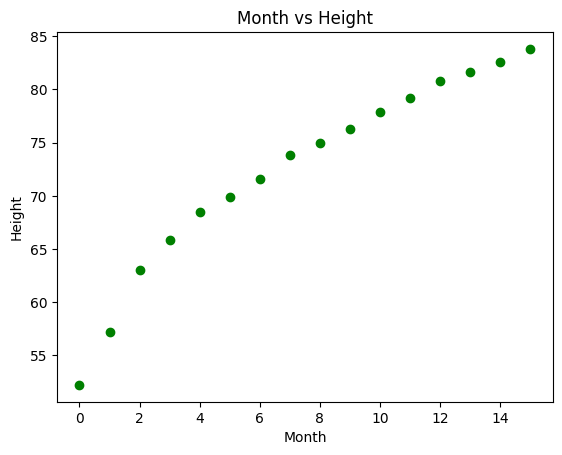

In [25]:
plot.scatter(dataframe.Mon, dataframe.Height, color='green')
plot.xlabel('Month')
plot.ylabel('Height')
plot.title('Month vs Height')
plot.show()

# 4. 建立線性回歸模型 (使用 random_state=18)

In [30]:
# 準備特徵 X 和目標 Y
x = dataframe.drop('Height', axis=1)
y = dataframe['Height']

# 分割訓練集和測試集 (test_size=0.2, random_state=18)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=18)

print('原始資料庫的維度分別是:', dataframe.shape)
print('訓練集維度:', x_train.shape)
print('測試集維度:', x_test.shape)

原始資料庫的維度分別是: (16, 2)
訓練集維度: (12, 1)
測試集維度: (4, 1)


# 5. 訓練線性回歸模型

In [31]:
# 建立線性回歸模型
model_0422 = LinearRegression()
model_0422.fit(x_train, y_train)

# 取出係數和截距
coefficient = model_0422.coef_[0]
intercept = model_0422.intercept_

print('===== 線性回歸模型結果 =====')
print(f'係數 (Coefficient): {coefficient}')
print(f'截距 (Intercept): {intercept}')

===== 線性回歸模型結果 =====
係數 (Coefficient): 1.957780261897157
截距 (Intercept): 57.58618652187799


# 6. 線性回歸方程式與均方差

In [36]:
# 預測測試集
y_pred = model_0422.predict(x_test)

# 計算均方差 (Mean Squared Error)
mse = mean_squared_error(y_pred, y_test)

print('===== 線性回歸方程式 =====')
print(f'Height = {coefficient:.4f} × Month + {intercept:.4f}')
print()
print('===== 均方差 (Mean Squared Error) =====')
print(f'MSE = {mse}')

===== 線性回歸方程式 =====
Height = 1.9578 × Month + 57.5862

===== 均方差 (Mean Squared Error) =====
MSE = 5.4036347821254


# 7. 繪製回歸線

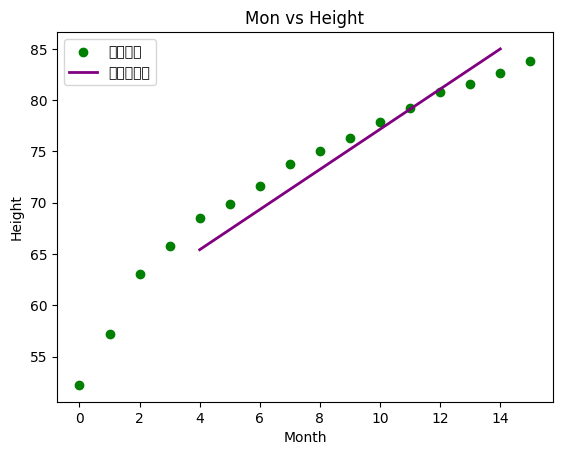

In [34]:
plot.scatter(x, y, color='green', label='實際資料')
plot.plot(x_test, y_pred, color='purple', linewidth=2, label='回歸預測線')
plot.xlabel('Month')
plot.ylabel('Height')
plot.title('Mon vs Height')
plot.legend()
plot.show()